# <center> Team SK-AI — Week 2: EDA & Preprocessing </center>

# **Dataset:** Pima Indians Diabetes Database  
**Target variable:** Outcome (0 = no diabetes, 1 = diabetes)  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('diabetes.csv')

---
# 1. Dataset Overview
**Owner: Tajimagambetova Symbat**

In [3]:
print(df.shape)

(768, 9)


The dataset has **768 rows** and **9 columns**. Each row is one patient record. There are 8 input features and 1 target column (Outcome).

In [4]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


All columns are numeric — no categorical data. Most columns are `int64` (whole numbers like counts and measurements). `BMI` and `DiabetesPedigreeFunction` are `float64` because they include decimal values. `Outcome` is stored as `int64` but works as a binary label (0 or 1).

In [5]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


There are no `NaN` values anywhere. However, this does not mean the data is clean — several columns contain **zeros that are biologically impossible**, which are effectively missing values in disguise. These are checked below.

In [6]:
bio_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(df[bio_cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

All five columns have zero values that cannot exist in a living person:

- **Glucose = 0** — a blood glucose level of zero is not compatible with life.
- **BloodPressure = 0** — zero blood pressure means no circulation.
- **SkinThickness = 0** — a person cannot have zero skin fold thickness.
- **Insulin = 0** — the body always produces some baseline insulin.
- **BMI = 0** — BMI is weight divided by height squared; a value of zero is physically impossible.

These zeros were used as placeholders for missing measurements and need to be handled in section 3.

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Key observations from the summary statistics:

**Minimums:** Glucose, BloodPressure, SkinThickness, Insulin, and BMI all show a minimum of 0, confirming the hidden missing values noted above. Pregnancies = 0 is fine (some women have had no pregnancies).

**Maximums:** Insulin reaches 846 µU/mL, which is far above the normal fasting range (2–25). This is likely an outlier. SkinThickness hits 99 mm, which is also unusually high. BMI = 67.1 is extreme but clinically possible (severe obesity).

**Means:** Average Glucose is 120.9, slightly above the normal fasting threshold (~100 mg/dL), which makes sense for a high-risk population. Average BMI is 32, placing the typical patient in the obese category.

Overall, Insulin has the most concerning distribution — both the zero problem (48.7% of rows) and the extreme maximum suggest it will need careful treatment.

In [8]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Class 0 (no diabetes) has **500 records (65.1%)** and class 1 (diabetes) has **268 records (34.9%)**. The classes are **not balanced** — there are roughly 1.87 times more negative cases than positive ones. This imbalance is moderate but significant enough to require stratification when splitting the data, so that both train and test sets preserve the same 65/35 ratio.

### Summary

This is the Pima Indians Diabetes Database, containing medical records of 768 female patients aged 21 and older. The goal is to predict whether a patient has Type 2 diabetes based on 8 clinical features. The data looks clean on the surface — no NaN values — but five columns contain biologically impossible zeros that act as hidden missing values. Insulin and SkinThickness are the worst affected, with 48.7% and 29.6% of their values being zero. The target variable is moderately imbalanced, and this needs to be accounted for during the train/test split.

---
# 2. Visualisations
**Owner: Batyrgeldi Insar**

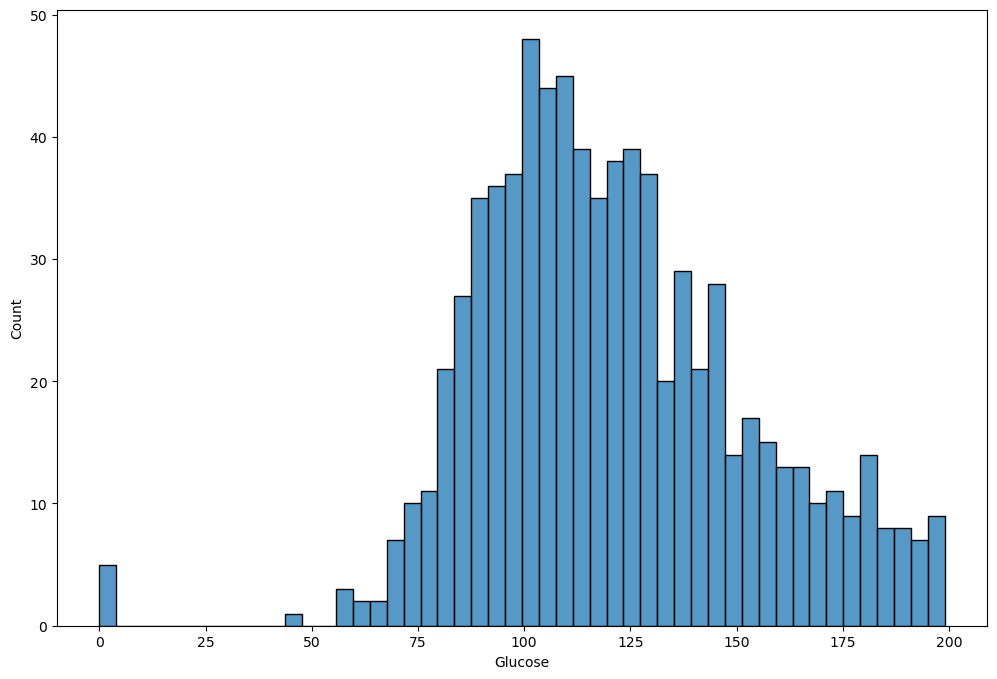

In [9]:
# Plot 1: Histogram
plt.figure(figsize=(12,8))
sns.histplot(df['Glucose'],kde=False,bins=50)
plt.show()

High glucose values are more common in patients with diabetes.This confirms its importance as a key feature for predicting Outcome

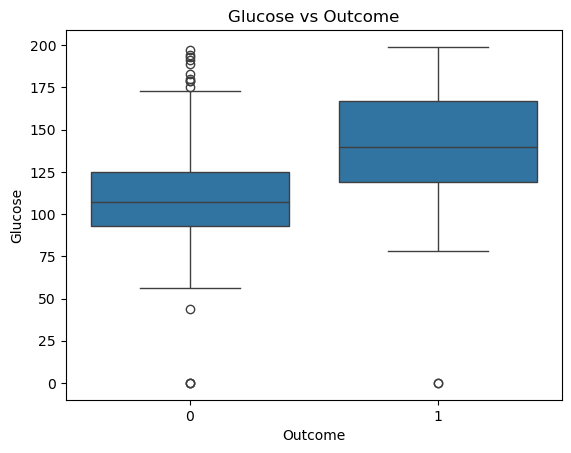

In [10]:
# Plot 2: Boxplot (numeric feature by Outcome)
plt.figure()
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose vs Outcome')
plt.show()

Patients with diabetes have significantly higher glucose levels, making this a strong predictor of the disease.However, there are also a large number of outliers in the patients who do not have diabetes,which can indicate that they might have hyperglycemia

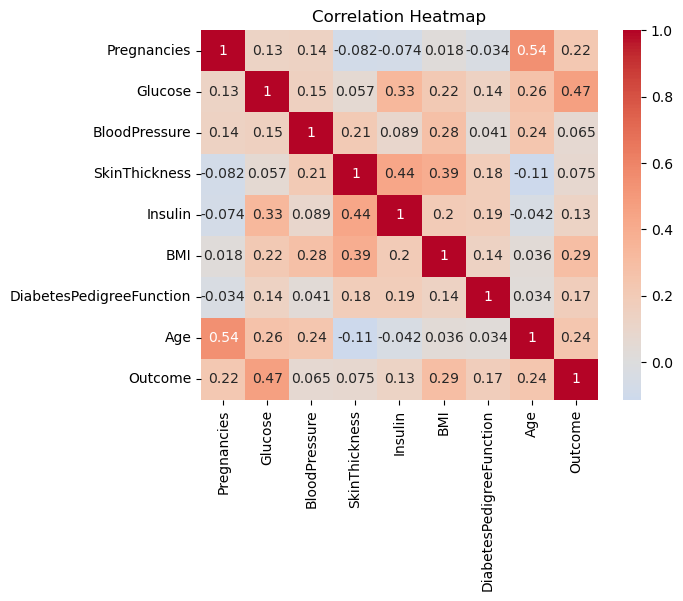

In [11]:
# Plot 3: Correlation heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

The strongest correlations with Outcome are observed for Glucose, BMI, and Age.They directly affect the likelihood of diabetes and should be key features in the model

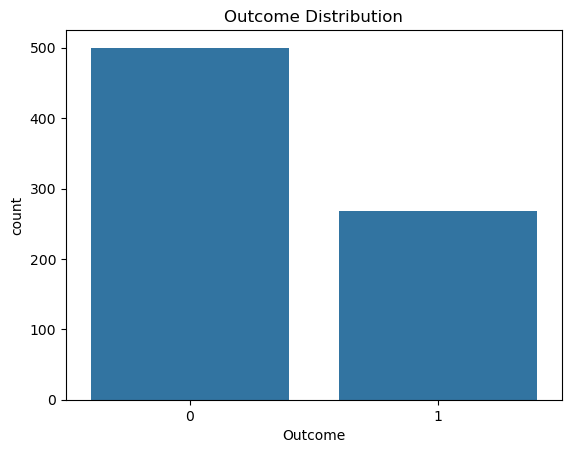

In [12]:
# Plot 4: Countplot of Outcome 
plt.figure()
sns.countplot(x='Outcome', data=df)
plt.title('Outcome Distribution')
plt.show()

There is an imbalance of classes - there are more patients without diabetes than with diabetes. This can cause the model to predict class 1 less well, so data balancing may be necessary

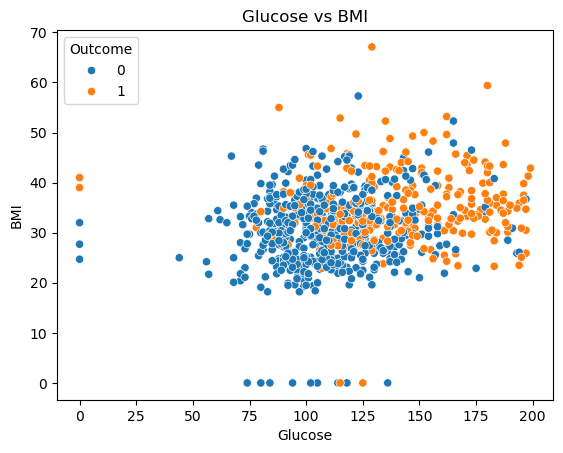

In [13]:
# Plot 5: Additional plot (Scatter plot)
plt.figure()
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title('Glucose vs BMI')
plt.show()

A combination of high glucose levels and a high BMI is more common in patients with diabetes.This highlights the importance of considering multiple factors simultaneously

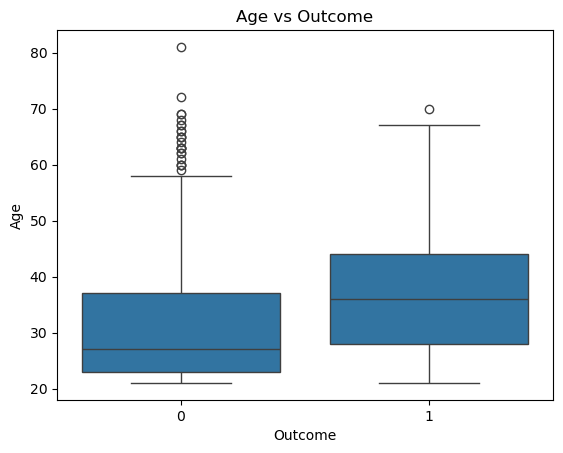

In [14]:
# Plot 6: Additional plot (Boxplot)
plt.figure()
sns.boxplot(x='Outcome', y='Age', data=df)
plt.title('Age vs Outcome')
plt.show()

Patients with diabetes are typically older, making this a good predictor of the disease.However, after a certain age threshold,it is almost certain that patient do not have diabetes

---
# 3. Missing Value Handling
**Owner: Magauya Kadyrzhan**
In the Pima dataset, missing values in clinical metrics are erroneously recorded as `0`. This is biologically impossible (e.g., blood pressure cannot be 0). We first replace these hidden missing values with `NaN` to assess their true volume, and then apply specific strategies for each column:

* **Glucose:** 5 missing values (0.65%). 
  * *Strategy:* Impute with Median.
  * *Reason:* The percentage is extremely small (< 1%), but rather than dropping rows (`dropna`), replacing with the median preserves our limited dataset without distorting the distribution.
* **BMI:** 11 missing values (1.43%).
  * *Strategy:* Impute with Median.
  * *Reason:* Very low missing rate. We use the median rather than the mean to avoid influence from extreme obesity outliers.
* **BloodPressure:** 35 missing values (4.56%).
  * *Strategy:* Impute with Median.
  * *Reason:* Missing rate is < 5%. The median is robust against severe clinical outliers in blood pressure.
* **SkinThickness:** 227 missing values (29.56%).
  * *Strategy:* Impute with Median grouped by `Outcome`.
  * *Reason:* A high missing rate (~30%). A simple global median would distort the data. Grouping by the target variable (`Outcome`) gives a much more accurate estimate based on whether the patient has diabetes or not.
* **Insulin:** 374 missing values (48.70%).
  * *Strategy:* Impute with Median grouped by `Outcome`.
  * *Reason:* Nearly half the data is missing. Dropping the column is not ideal as insulin is a key diabetes indicator. Grouping by `Outcome` is the safest strategy to preserve the feature without introducing massive global bias.

In [15]:
# 1. Replace biologically impossible 0s with NaN
hidden_nan_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[hidden_nan_cols] = df[hidden_nan_cols].replace(0, np.nan)

print("--- Missing Values BEFORE Imputation ---")
print(df.isnull().sum())
print("\n")

# 2. Impute columns with low missing rates (< 5%) with global median
# FIX: Removed inplace=True to comply with Pandas 3.0 standards
for col in ['Glucose', 'BMI', 'BloodPressure']:
    df[col] = df[col].fillna(df[col].median())

# 3. Impute columns with high missing rates with median grouped by Outcome
# FIX: Removed inplace=True to comply with Pandas 3.0 standards
for col in ['SkinThickness', 'Insulin']:
    df[col] = df[col].fillna(df.groupby('Outcome')[col].transform('median'))

# 4. Confirm no missing values remain (Strict Requirement)
print("--- Missing Values AFTER Imputation ---")
print(df.isnull().sum())

--- Missing Values BEFORE Imputation ---
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


--- Missing Values AFTER Imputation ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


---
# 4. Feature Engineering


**Owner: Oryngulova Aidana**

In this section, we create new features based on existing medical indicators to improve the predictive power of the model. Since all original features are numerical, no encoding is required.

We also apply transformations to reduce the effect of skewed distributions and outliers.

In [16]:
# New feature: Glucose_BMI interaction
df['Glucose_BMI'] = df['Glucose'] * df['BMI']

df[['Glucose', 'BMI', 'Glucose_BMI']].head()

,Glucose,BMI,Glucose_BMI
0,148.0,33.6,4972.8
1,85.0,26.6,2261.0
2,183.0,23.3,4263.9
3,89.0,28.1,2500.9
4,137.0,43.1,5904.7


We created a new feature **Glucose_BMI** as the product of Glucose and BMI.

**Why:** Both Glucose and BMI are strongly associated with diabetes. Their interaction may better capture combined risk (e.g., high glucose + high BMI = very high risk).

In [17]:
# Create age group feature
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 100],
                         labels=[0, 1, 2, 3, 4])

df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,50,2
1,31,1
2,32,1
3,21,0
4,33,1


We created **Age_Group** by binning Age into categories.

**Why:** Diabetes risk increases with age, but not always linearly. Grouping ages helps the model capture non-linear patterns.

In [18]:
# Log transformation for skewed feature
df['Insulin_log'] = np.log1p(df['Insulin'])

df[['Insulin', 'Insulin_log']].head()

,Insulin,Insulin_log
0,169.5,5.138735
1,102.5,4.639572
2,169.5,5.138735
3,94.0,4.553877
4,168.0,5.129899


We applied a **log transformation** to Insulin.

**Why:** Insulin has extreme outliers and a highly skewed distribution. Log transformation reduces skewness and stabilizes variance, improving model performance.

In [19]:
# Check for new issues
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucose_BMI                 0
Age_Group                   0
Insulin_log                 0
dtype: int64

We verified that no new missing or infinite values were introduced during feature engineering.

In [20]:
features = df.drop(columns=['Outcome']).columns
features

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_BMI', 'Age_Group',
       'Insulin_log'],
      dtype='object')

Final features used for modeling include original variables plus engineered ones:

- Glucose_BMI
- Age_Group
- Insulin_log


### Encoding

The dataset does not contain any categorical features — all variables are numerical. Therefore, no encoding techniques (such as one-hot or label encoding) are required.

---
# 5. Scaling
**Owner: Magauya Kadyrzhan**

In [22]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform ONLY on the training data to prevent Data Leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data based on the training data parameters
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to display the results clearly
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Print first rows to confirm scaling was applied (Strict Requirement)
print("First 5 rows of SCALED X_train data:\n")
display(X_train_scaled_df.head())

First 5 rows of SCALED X_train data:



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI,Age_Group,Insulin_log
0,-0.851355,-1.056427,-0.826740,-1.895290,-1.170378,-0.769477,0.310794,-0.792169,-1.070048,-0.765444,-1.983819
1,0.356576,0.144399,0.477772,-0.224736,-1.427642,-0.417498,-0.116439,0.561034,-0.182996,0.119646,-3.243361
2,-0.549372,-0.556083,-1.152868,1.223078,-0.545594,0.359790,-0.764862,-0.707594,-0.228055,-0.765444,-0.489352
3,-0.851355,0.811525,-1.315932,-0.224736,-0.441463,-0.402832,0.262314,-0.369293,0.236858,-0.765444,-0.322962
4,-1.153338,-0.889646,-0.663676,1.111708,-0.410836,1.782373,-0.337630,-0.961320,0.168198,-0.765444,-0.276620


* **Choice of Scaler:** We chose `StandardScaler` over `MinMaxScaler`. Many features in our dataset (like Insulin and BMI) contain natural clinical outliers. MinMaxScaler would compress the normal data distribution too tightly between 0 and 1. StandardScaler handles these outliers much better by standardizing the mean to 0 and variance to 1.
* **Data Leakage Prevention:** It is critical that the scaler is NOT trained on the entire dataset. If we fit the scaler on all data, information about the test set (future data) "leaks" into the training set, artificially inflating model accuracy. Therefore, we use `fit_transform` ONLY on `X_train`, and strictly `transform` on `X_test`.

---
# 6. Train/Test Split
**Owner: Tajimagambetova Symbat**

In [23]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)
print()
print("Class balance check:")
print(f"  Train — class 0: {(y_train==0).sum()}, class 1: {(y_train==1).sum()} | class 1 share: {y_train.mean():.3f}")
print(f"  Test  — class 0: {(y_test==0).sum()},  class 1: {(y_test==1).sum()}  | class 1 share: {y_test.mean():.3f}")

X_train: (614, 11)
X_test:  (154, 11)
y_train: (614,)
y_test:  (154,)

Class balance check:
  Train — class 0: 400, class 1: 214 | class 1 share: 0.349
  Test  — class 0: 100,  class 1: 54  | class 1 share: 0.351


**`test_size=0.2`** — 20% of the data (154 rows) goes to the test set and 80% (614 rows) to training. This is a standard split that gives the model enough data to learn from while keeping a meaningful evaluation set.

**`random_state=42`** — fixes the random seed so the split is reproducible. Without it, every run would produce a different split and results could not be compared or replicated.

**`stratify=y`** — ensures that the 65/35 class ratio is preserved in both train and test sets. Without stratification, a random split on imbalanced data can accidentally put too few positive cases in the test set, which would give a misleading evaluation score.

**Size check:** 614 + 154 = 768 — matches the full dataset. The class 1 share is ~0.349 in both sets, confirming stratification worked correctly.